# Capítulo 7.8 — Laboratório: modelagem não linear

Este notebook traduz e executa o laboratório de modelagem não linear do capítulo 7 de *An Introduction to Statistical Learning with Applications in Python*.

O conjunto `Wage` será usado como exemplo contínuo. O objetivo é comparar formas de representar relações não lineares entre idade, ano, escolaridade e salário:

1. regressão polinomial e funções degrau;
2. splines de regressão e splines naturais;
3. splines de suavização e modelos aditivos generalizados, os GAMs;
4. regressão local.

As explicações seguem a ordem do capítulo. Após as saídas, há comentários sobre o que cada resultado permite concluir e quais limitações permanecem.

> **Unidade da resposta:** no conjunto `Wage`, a variável `wage` é medida em milhares de dólares por ano. Assim, `wage = 100` representa aproximadamente US$ 100 mil anuais.

## Contexto da Figura 7.14

Antes do laboratório, o capítulo apresenta a Figura 7.14, que repete o GAM da Figura 7.13 após excluir observações cuja escolaridade é inferior ao ensino médio (`< HS`). A retirada desse grupo resolve um problema de separação observado no exemplo de alta renda: não há pessoas com salário acima de US$ 250 mil nessa categoria. Com os grupos restantes, o gráfico passa a mostrar de forma mais estável a associação positiva entre escolaridade e salário.

Esse ponto será reproduzido nas células do GAM logístico. Primeiro veremos o ajuste instável com todas as categorias e, depois, o novo ajuste sem a categoria `< HS`.

## Preparação do ambiente

O bloco abaixo instala apenas os pacotes que estiverem ausentes. Isso torna o notebook executável em um ambiente novo sem reinstalar bibliotecas já disponíveis.

In [1]:
import importlib.util
import subprocess
import sys

pacotes = {
    "ISLP": "ISLP",
    "pygam": "pygam",
    "statsmodels": "statsmodels",
}

ausentes = [pip_nome for modulo, pip_nome in pacotes.items()
            if importlib.util.find_spec(modulo) is None]

if ausentes:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *ausentes]
    )

print("Dependências prontas para uso.")

Dependências prontas para uso.


In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import summarize, poly, ModelSpec as MS
from ISLP.transforms import BSpline, NaturalSpline
from ISLP.models import bs, ns

from pygam import (
    s as s_gam,
    l as l_gam,
    f as f_gam,
    LinearGAM,
    LogisticGAM,
)
from ISLP.pygam import (
    approx_lam,
    degrees_of_freedom,
    plot as plot_gam,
    anova as anova_gam,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (9, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Bibliotecas importadas.")

Bibliotecas importadas.


In [3]:
Wage = load_data("Wage")
y = Wage["wage"]
age = Wage["age"]

print(f"Dimensão do conjunto: {Wage.shape[0]} linhas e {Wage.shape[1]} colunas")
display(Wage.head())
display(Wage[["age", "year", "wage"]].describe().T)

Dimensão do conjunto: 3000 linhas e 11 colunas


,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.3181,75.0432
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.2553,70.4760
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.8751,130.9822
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.0414,154.6853
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.3181,75.0432


,count,mean,std,min,25%,50%,75%,max
age,"3,000.0000",42.4147,11.5424,18.0000,33.7500,42.0000,51.0000,80.0000
year,"3,000.0000","2,005.7910",2.0262,"2,003.0000","2,004.0000","2,006.0000","2,008.0000","2,009.0000"
wage,"3,000.0000",111.7036,41.7286,20.0855,85.3839,104.9215,128.6805,318.3424


O conjunto contém 3.000 trabalhadores. `wage` será a resposta na maior parte do laboratório. `age`, `year` e `education` serão usadas para mostrar como diferentes bases e penalizações representam relações não lineares.

A análise é explicativa e usa os próprios dados de treinamento para visualizar o ajuste. Quando o objetivo for escolher um modelo para previsão fora da amostra, a comparação deve incluir validação cruzada ou um conjunto de teste.

# 7.8.1 Regressão polinomial e funções degrau

## Regressão polinomial de quarto grau

Começamos reproduzindo a lógica da Figura 7.1. A função `poly()` cria uma base polinomial ortogonal. Em vez de inserir diretamente $age$, $age^2$, $age^3$ e $age^4$, ela produz colunas ortogonais que descrevem o mesmo espaço funcional e reduzem problemas numéricos causados pela forte correlação entre potências da mesma variável.

O método `fit()` aprende no conjunto de treinamento os parâmetros necessários para construir a base. O método `transform()` reaplica exatamente essa transformação a dados novos. Essa separação evita recalcular a base de forma incompatível no momento da previsão.

In [4]:
poly_age = MS([poly("age", degree=4)]).fit(Wage)
X_poly4 = poly_age.transform(Wage)
M_poly4 = sm.OLS(y, X_poly4).fit()

summarize(M_poly4)

,coef,std err,t,P>|t|
intercept,111.7036,0.7290,153.2830,0.0000
"poly(age, degree=4)[0]",447.0679,39.9150,11.2010,0.0000
"poly(age, degree=4)[1]",-478.3158,39.9150,-11.9830,0.0000
"poly(age, degree=4)[2]",125.5217,39.9150,3.1450,0.0020
"poly(age, degree=4)[3]",-77.9112,39.9150,-1.9520,0.0510


**Avaliação do resultado.** Os três primeiros componentes polinomiais apresentam evidência estatística de associação com salário. O quarto componente fica no limite de 5%. Os coeficientes da base ortogonal não devem ser lidos como “efeito de um ano de idade”, pois cada coluna representa uma combinação das potências de `age`. A forma da relação é interpretada pela curva prevista.

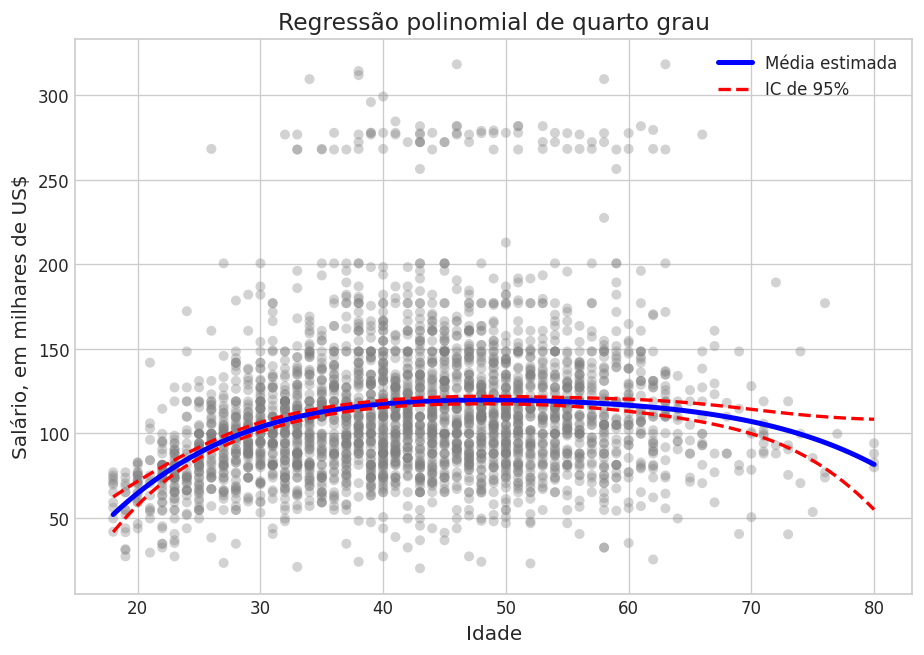

In [5]:
age_grid = np.linspace(age.min(), age.max(), 100)
age_df = pd.DataFrame({"age": age_grid})


def plot_wage_fit(age_df, basis, title):
    # Ajusta OLS na base recebida e desenha média e IC de 95%.
    X = basis.transform(Wage)
    Xnew = basis.transform(age_df)
    model = sm.OLS(y, X).fit()
    preds = model.get_prediction(Xnew)
    bands = preds.conf_int(alpha=0.05)

    fig, ax = subplots(figsize=(9, 6))
    ax.scatter(age, y, facecolor="gray", edgecolor="none", alpha=0.35)
    ax.plot(age_grid, preds.predicted_mean, "b", linewidth=3,
            label="Média estimada")
    ax.plot(age_grid, bands[:, 0], "r--", linewidth=2,
            label="IC de 95%")
    ax.plot(age_grid, bands[:, 1], "r--", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Idade")
    ax.set_ylabel("Salário, em milhares de US$")
    ax.legend()
    plt.show()
    return model


_ = plot_wage_fit(
    age_df,
    poly_age,
    "Regressão polinomial de quarto grau"
)

**Leitura do gráfico.** O salário médio cresce com a idade no começo da vida profissional, atinge uma faixa relativamente estável na meia-idade e tende a cair nas idades mais altas. As bandas se alargam nas extremidades porque há menos observações jovens e idosas. A transparência definida por `alpha=0.35` faz regiões com muitos pontos sobrepostos parecerem mais densas. A oscilação final deve ser tratada com cautela: polinômios têm comportamento global, então uma alteração em uma região pode mudar a curva inteira e produzir extrapolações instáveis.

## Escolha do grau por ANOVA

Escolher o grau apenas pela aparência da curva abre espaço para complexidade desnecessária. A ANOVA compara modelos aninhados por meio de testes F. Em cada linha, a hipótese nula afirma que o modelo mais simples já é suficiente; a alternativa afirma que o termo de grau seguinte reduz o erro de forma relevante. O asterisco em `anova_lm(*ajustes_poly)` desempacota a lista e entrega cada modelo ajustado como um argumento separado da função.

In [6]:
modelos_poly = [MS([poly("age", degree=d)]) for d in range(1, 6)]
Xs_poly = [modelo.fit_transform(Wage) for modelo in modelos_poly]
ajustes_poly = [sm.OLS(y, X_).fit() for X_ in Xs_poly]

tabela_anova_poly = anova_lm(*ajustes_poly)
tabela_anova_poly.index = ["grau 1", "grau 2", "grau 3", "grau 4", "grau 5"]
tabela_anova_poly

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
grau 1,"2,998.0000","5,022,216.1047",0.0000,NaN,NaN,NaN
grau 2,"2,997.0000","4,793,430.0946",1.0000,"228,786.0101",143.5931,0.0000
grau 3,"2,996.0000","4,777,674.4010",1.0000,"15,755.6937",9.8888,0.0017
grau 4,"2,995.0000","4,771,604.2488",1.0000,"6,070.1521",3.8098,0.0510
grau 5,"2,994.0000","4,770,321.6858",1.0000,"1,282.5630",0.8050,0.3697


**Avaliação do resultado.** A passagem do modelo linear para o quadrático reduz fortemente a soma dos quadrados dos resíduos, com valor-p praticamente nulo. O termo cúbico ainda produz ganho, com valor-p próximo de 0,0017. A passagem do grau 3 para o grau 4 fica perto do limiar de 5%, enquanto o quinto grau não encontra suporte nos dados, com valor-p em torno de 0,37.

Um polinômio cúbico oferece a escolha mais parcimoniosa. O quarto grau também é defensável se a pequena mudança de curvatura tiver valor substantivo. O quinto grau acrescenta flexibilidade sem redução convincente do erro.

In [7]:
comparacao_t_f = pd.DataFrame({
    "termo": ["quadrático sobre linear", "cúbico sobre quadrático",
              "quártico sobre cúbico"],
    "t² do resumo do grau 4": np.square(M_poly4.tvalues.iloc[2:5].to_numpy()),
    "F da ANOVA": tabela_anova_poly["F"].iloc[1:4].to_numpy(),
})
comparacao_t_f["diferença absoluta"] = (
    comparacao_t_f["t² do resumo do grau 4"] - comparacao_t_f["F da ANOVA"]
).abs()
comparacao_t_f

,termo,t² do resumo do grau 4,F da ANOVA,diferença absoluta
0,quadrático sobre linear,143.6025,143.5931,0.0094
1,cúbico sobre quadrático,9.8894,9.8888,0.0006
2,quártico sobre cúbico,3.8101,3.8098,0.0002


Como `poly()` constrói componentes ortogonais, o quadrado da estatística t de cada novo componente coincide com a estatística F da comparação entre graus sucessivos, salvo arredondamento. A ANOVA continua válida com polinômios comuns, desde que os modelos sejam aninhados.

Também podemos verificar se a curvatura de idade permanece necessária após controlar a escolaridade.

In [8]:
modelos_educ = [
    MS(["education", poly("age", degree=d)])
    for d in range(1, 4)
]
Xs_educ = [modelo.fit_transform(Wage) for modelo in modelos_educ]
ajustes_educ = [sm.OLS(y, X_).fit() for X_ in Xs_educ]

tabela_anova_educ = anova_lm(*ajustes_educ)
tabela_anova_educ.index = ["idade linear", "idade quadrática", "idade cúbica"]
tabela_anova_educ

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
idade linear,"2,997.0000","3,902,335.0315",0.0000,NaN,NaN,NaN
idade quadrática,"2,996.0000","3,759,472.3303",1.0000,"142,862.7012",113.9919,0.0000
idade cúbica,"2,995.0000","3,753,546.1233",1.0000,"5,926.2071",4.7286,0.0297


A inclusão do termo quadrático continua claramente sustentada mesmo após controlar escolaridade. O termo cúbico apresenta valor-p em torno de 0,03, sinal de que ainda há alguma curvatura não capturada pelo modelo quadrático. Para uma decisão preditiva, a validação cruzada seria preferível porque avalia erro fora da amostra, enquanto estes testes avaliam ganho de ajuste dentro da amostra sob hipóteses paramétricas.

## Regressão logística polinomial para alta renda

Agora a resposta indica se o salário anual supera US$ 250 mil. Ajustamos um GLM binomial com a mesma base polinomial de quarto grau. A média prevista passa a representar uma probabilidade.

In [9]:
Wage["high_earn"] = Wage["wage"] > 250
high_earn = Wage["high_earn"]

glm_poly = sm.GLM(
    high_earn.astype(int),
    X_poly4,
    family=sm.families.Binomial(),
)
B_poly = glm_poly.fit()

print(f"Casos de alta renda: {high_earn.sum()} de {len(high_earn)} "
      f"({high_earn.mean():.2%})")
summarize(B_poly)

Casos de alta renda: 79 de 3000 (2.63%)


,coef,std err,z,P>|z|
intercept,-4.3012,0.3450,-12.4570,0.0000
"poly(age, degree=4)[0]",71.9642,26.1330,2.7540,0.0060
"poly(age, degree=4)[1]",-85.7729,35.9290,-2.3870,0.0170
"poly(age, degree=4)[2]",34.1626,19.6970,1.7340,0.0830
"poly(age, degree=4)[3]",-47.4008,24.1050,-1.9660,0.0490


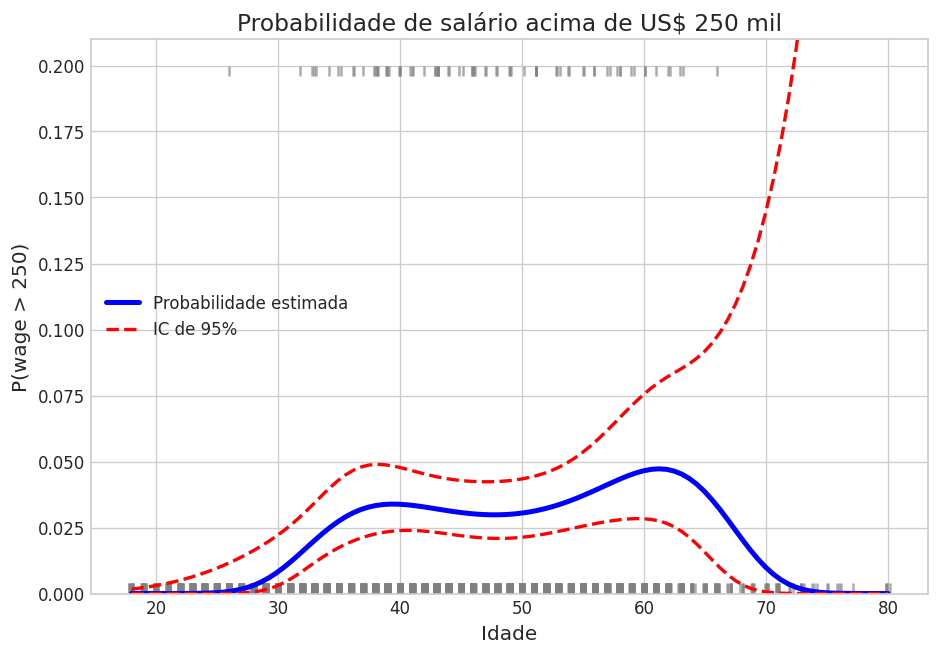

In [10]:
newX = poly_age.transform(age_df)
preds_logit = B_poly.get_prediction(newX)
bands_logit = preds_logit.conf_int(alpha=0.05)

fig, ax = subplots(figsize=(9, 6))
rng = np.random.default_rng(0)
idade_jitter = age + 0.2 * rng.uniform(-1, 1, size=len(age))

ax.scatter(
    idade_jitter,
    np.where(high_earn, 0.198, 0.002),
    color="gray",
    marker="|",
    alpha=0.65,
)
ax.plot(age_grid, preds_logit.predicted_mean, "b", linewidth=3,
        label="Probabilidade estimada")
ax.plot(age_grid, bands_logit[:, 0], "r--", linewidth=2,
        label="IC de 95%")
ax.plot(age_grid, bands_logit[:, 1], "r--", linewidth=2)
ax.set_title("Probabilidade de salário acima de US$ 250 mil")
ax.set_xlabel("Idade")
ax.set_ylabel("P(wage > 250)")
ax.set_ylim(0, 0.21)
ax.legend()
plt.show()

As marcas verticais formam um *rug plot*. Casos acima de US$ 250 mil aparecem no topo e os demais na base. Um pequeno *jitter* horizontal impede que pessoas com a mesma idade fiquem completamente sobrepostas.

A probabilidade prevista é baixa em todo o intervalo porque alta renda é rara na amostra. Ela cresce até a meia-idade e depois recua. As bandas largas nas extremidades refletem poucos eventos e menor densidade de dados. Este gráfico descreve associação marginal com idade; não controla escolaridade ou ano.

## Função degrau

Uma função degrau troca a curva contínua por médias constantes em intervalos. `pd.qcut(age, 4)` escolhe os pontos de corte pelos quartis, formando grupos com tamanhos semelhantes. `pd.get_dummies()` cria uma coluna indicadora para cada grupo.

In [11]:
cut_age = pd.qcut(age, 4)
X_step = pd.get_dummies(cut_age).astype(float)
modelo_step = sm.OLS(y, X_step).fit()

resumo_step = summarize(modelo_step)
resumo_step.index.name = "faixa de idade"
resumo_step

,coef,std err,t,P>|t|
faixa de idade,,,,
"(17.999, 33.75]",94.1584,1.4780,63.6920,0.0000
"(33.75, 42.0]",116.6608,1.4700,79.3850,0.0000
"(42.0, 51.0]",119.1887,1.4160,84.1470,0.0000
"(51.0, 80.0]",116.5717,1.5590,74.7510,0.0000


Como o modelo usa todas as categorias e não adiciona intercepto, cada coeficiente é o salário médio de sua faixa. A média cresce com a idade até o terceiro intervalo e recua levemente no quarto. A função degrau é fácil de comunicar, mas cria saltos artificiais nos pontos de corte: pessoas separadas por poucos meses podem receber previsões distintas.

Se os cortes fossem definidos por conhecimento do problema, usaríamos `pd.cut()`. Quartis equilibram o número de observações, mas não garantem faixas substantivamente relevantes.

# 7.8.2 Splines

Splines representam a relação por polinômios conectados em pontos chamados nós. Uma base B-spline cúbica mantém continuidade e suavidade nas junções. O método oferece flexibilidade local: alterar o ajuste em uma região afeta menos as demais regiões do que em um polinômio global.

`BSpline()` é o transformador que calcula a matriz da base. O auxiliar `bs()` integra essa transformação ao construtor de matrizes de modelo do `ISLP`.

In [12]:
bs_direta = BSpline(
    internal_knots=[25, 40, 60],
    intercept=True,
).fit(age)
matriz_bs_direta = bs_direta.transform(age)

print("Dimensão da base B-spline com intercepto:", matriz_bs_direta.shape)

Dimensão da base B-spline com intercepto: (3000, 7)


Três nós internos e grau cúbico geram sete funções de base quando o intercepto faz parte da própria base. No modelo seguinte, `bs()` omite uma dessas colunas porque o construtor já adiciona um intercepto global.

In [13]:
bs_age = MS([
    bs(
        "age",
        internal_knots=[25, 40, 60],
        name="bs(age, knots)",
    )
])
Xbs = bs_age.fit_transform(Wage)
M_bs = sm.OLS(y, Xbs).fit()

summarize(M_bs)

,coef,std err,t,P>|t|
intercept,60.4937,9.4600,6.3940,0.0000
"bs(age, knots)[0]",3.9805,12.5380,0.3170,0.7510
"bs(age, knots)[1]",44.6310,9.6260,4.6360,0.0000
"bs(age, knots)[2]",62.8388,10.7550,5.8430,0.0000
"bs(age, knots)[3]",55.9908,10.7060,5.2300,0.0000
"bs(age, knots)[4]",50.6881,14.4020,3.5200,0.0000
"bs(age, knots)[5]",16.6061,19.1260,0.8680,0.3850


Há seis coeficientes de spline e um intercepto global. Os coeficientes individuais descrevem pesos das funções de base e não efeitos isolados de idade. Testar cada peso separadamente raramente responde à pergunta substantiva. A curva prevista e uma comparação conjunta contra um modelo mais simples são mais úteis.

Também podemos informar a complexidade por graus de liberdade. Com `df=6`, o transformador escolhe três nós nos quartis da idade.

In [14]:
nos_df6 = BSpline(df=6).fit(age).internal_knots_
print("Nós internos escolhidos para df=6:", nos_df6)

bs_age0 = MS([bs("age", df=3, degree=0)]).fit(Wage)
Xbs0 = bs_age0.transform(Wage)
M_bs0 = sm.OLS(y, Xbs0).fit()

summarize(M_bs0)

Nós internos escolhidos para df=6: [33.75 42.   51.  ]


,coef,std err,t,P>|t|
intercept,94.1584,1.4780,63.6870,0.0000
"bs(age, df=3, degree=0)[0]",22.3490,2.1520,10.3880,0.0000
"bs(age, df=3, degree=0)[1]",24.8076,2.0440,12.1370,0.0000
"bs(age, df=3, degree=0)[2]",22.7814,2.0870,10.9170,0.0000


Uma spline de grau zero é constante por partes, como a função degrau. A diferença está na codificação. No modelo com `qcut()`, cada coeficiente é diretamente uma média. Na spline, o intercepto é a média da primeira faixa e os outros coeficientes são diferenças em relação a ela.

In [15]:
medias_qcut = y.groupby(cut_age, observed=True).mean().to_numpy()
medias_bs0_pelos_coef = np.r_[
    M_bs0.params.iloc[0],
    M_bs0.params.iloc[0] + M_bs0.params.iloc[1:].to_numpy(),
]

comparacao_degraus = pd.DataFrame({
    "faixa": [str(v) for v in cut_age.cat.categories],
    "média por qcut": medias_qcut,
    "média reconstruída pela spline grau 0": medias_bs0_pelos_coef,
})
comparacao_degraus["diferença"] = (
    comparacao_degraus["média por qcut"]
    - comparacao_degraus["média reconstruída pela spline grau 0"]
)
comparacao_degraus

,faixa,média por qcut,média reconstruída pela spline grau 0,diferença
0,"(17.999, 33.75]",94.1584,94.1584,0.0000
1,"(33.75, 42.0]",116.6608,116.5074,0.1534
2,"(42.0, 51.0]",119.1887,118.9660,0.2226
3,"(51.0, 80.0]",116.5717,116.9398,-0.3681


Os valores quase coincidem. Pequenas diferenças surgem nos próprios pontos de corte: `qcut()` e a base spline adotam convenções distintas para decidir se um valor exatamente igual ao nó entra no intervalo da esquerda ou da direita.

## Spline natural

Uma spline natural impõe comportamento linear além dos nós de fronteira. Essa restrição reduz a variância nas extremidades, região em que splines cúbicas comuns costumam ser instáveis.

In [16]:
ns_age = MS([ns("age", df=5)]).fit(Wage)
M_ns = sm.OLS(y, ns_age.transform(Wage)).fit()

summarize(M_ns)

,coef,std err,t,P>|t|
intercept,60.4752,4.7080,12.8440,0.0000
"ns(age, df=5)[0]",61.5267,4.7090,13.0650,0.0000
"ns(age, df=5)[1]",55.6912,5.7170,9.7410,0.0000
"ns(age, df=5)[2]",46.8184,4.9480,9.4630,0.0000
"ns(age, df=5)[3]",83.2036,11.9180,6.9820,0.0000
"ns(age, df=5)[4]",6.8770,9.4840,0.7250,0.4680


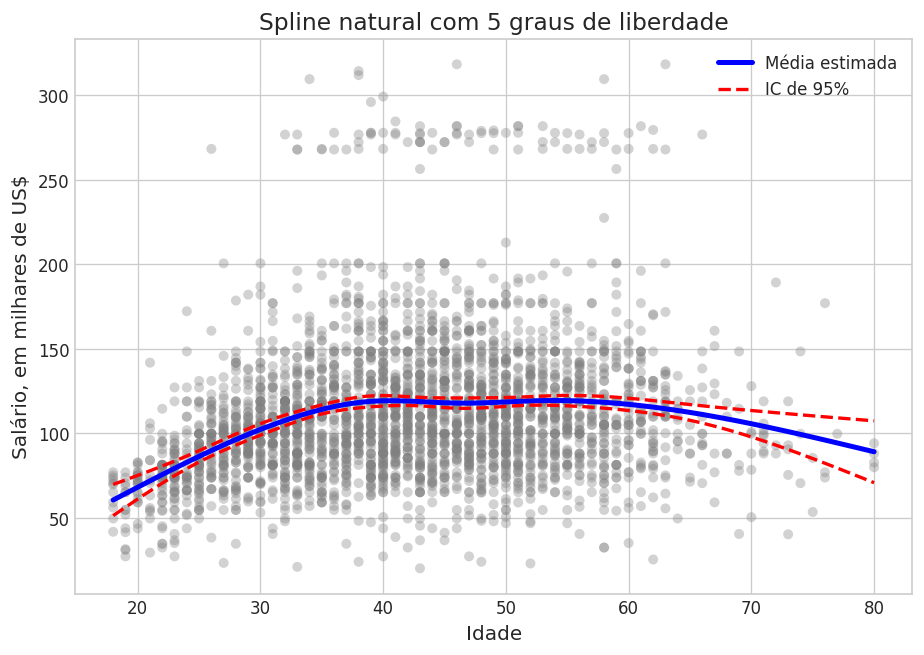

In [17]:
_ = plot_wage_fit(
    age_df,
    ns_age,
    "Spline natural com 5 graus de liberdade"
)

A spline natural recupera a mesma estrutura geral do polinômio: crescimento no início da carreira, estabilização e queda em idades avançadas. A principal diferença está nas caudas, forçadas a seguir linhas retas. Isso tende a produzir comportamento mais estável perto dos limites observados, embora não torne segura a extrapolação para idades fora da amostra.

# 7.8.3 Splines de suavização e GAMs

Uma spline de suavização com erro quadrático pode ser vista como um GAM com uma única variável. A função ajustada equilibra aderência aos dados e suavidade. O parâmetro de penalização $\lambda$ controla esse equilíbrio:

- $\lambda$ pequeno permite mais curvatura e pode capturar ruído;
- $\lambda$ grande penaliza oscilações e aproxima o ajuste de uma reta.

No `pygam`, `s_gam(0)` associa uma spline de suavização à coluna 0 da matriz de atributos. `l_gam()` representa um termo linear e `f_gam()` trata uma coluna como fator categórico.

In [18]:
X_age = np.asarray(age).reshape((-1, 1))

gam = LinearGAM(s_gam(0, lam=0.6)).fit(X_age, y)
gam

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + intercept, tol=0.0001, 
   verbose=False)

`pygam` espera uma matriz bidimensional de atributos. Por isso, `age` foi convertida de vetor para uma matriz com uma coluna. O `-1` em `reshape((-1, 1))` pede ao NumPy que determine automaticamente o número de linhas.

## Efeito de $\lambda$

λ selecionado pela busca em grade: [[np.float64(251.18864315095772)]]
Graus de liberdade efetivos: 5.644


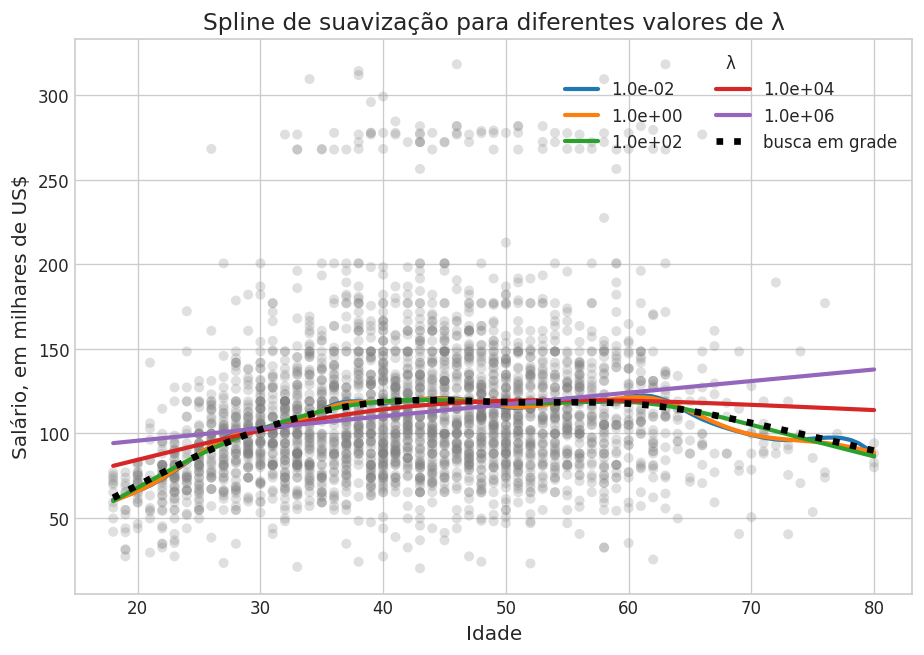

In [19]:
fig, ax = subplots(figsize=(9, 6))
ax.scatter(age, y, facecolor="gray", edgecolor="none", alpha=0.25)

for lam in np.logspace(-2, 6, 5):
    gam_lam = LinearGAM(s_gam(0, lam=lam)).fit(X_age, y)
    ax.plot(
        age_grid,
        gam_lam.predict(age_grid),
        label=f"{lam:.1e}",
        linewidth=2.5,
    )

gam_busca = LinearGAM(s_gam(0)).gridsearch(
    X_age,
    y,
    progress=False,
)
ax.plot(
    age_grid,
    gam_busca.predict(age_grid),
    color="black",
    linestyle=":",
    label="busca em grade",
    linewidth=4,
)
ax.set_xlabel("Idade")
ax.set_ylabel("Salário, em milhares de US$")
ax.set_title("Spline de suavização para diferentes valores de λ")
ax.legend(title="λ", ncol=2)
plt.show()

print("λ selecionado pela busca em grade:", gam_busca.lam)
print("Graus de liberdade efetivos:",
      round(gam_busca.statistics_["edof"], 3))

As curvas com penalização pequena são mais onduladas. À medida que $\lambda$ cresce, o ajuste perde flexibilidade. A busca em grade escolhe o valor que otimiza o critério interno do `pygam`, o GCV para este caso. O grau de liberdade efetivo resume a complexidade realmente usada após a penalização.

Fixar graus de liberdade costuma ser mais interpretável do que escolher $\lambda$ diretamente. O próximo bloco procura valores de $\lambda$ que produzam complexidades especificadas.

In [20]:
gam_base = LinearGAM(s_gam(0)).fit(X_age, y)
age_term_univariado = gam_base.terms[0]
lam_4 = approx_lam(X_age, age_term_univariado, 4)
age_term_univariado.lam = lam_4

print("λ aproximado para 4 graus de liberdade:", lam_4)
print("Graus de liberdade obtidos:",
      degrees_of_freedom(X_age, age_term_univariado))

λ aproximado para 4 graus de liberdade: [1446.68511262]
Graus de liberdade obtidos: 4.000000100003876


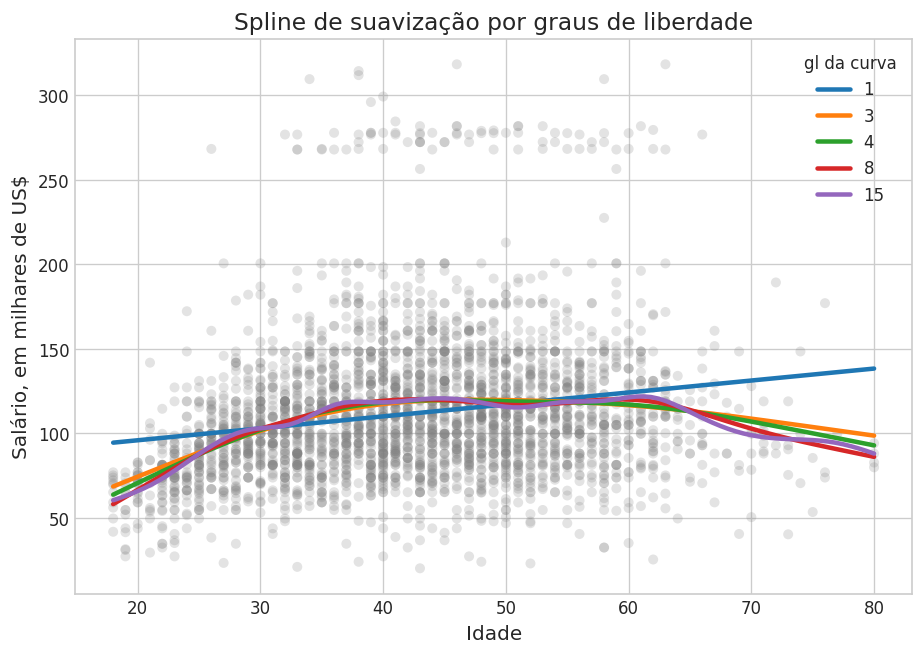

In [21]:
fig, ax = subplots(figsize=(9, 6))
ax.scatter(age, y, facecolor="gray", edgecolor="none", alpha=0.22)

for df_curva in [1, 3, 4, 8, 15]:
    lam_df = approx_lam(X_age, age_term_univariado, df_curva + 1)
    age_term_univariado.lam = lam_df
    gam_df = LinearGAM(age_term_univariado).fit(X_age, y)
    ax.plot(
        age_grid,
        gam_df.predict(age_grid),
        label=str(df_curva),
        linewidth=2.7,
    )

ax.set_xlabel("Idade")
ax.set_ylabel("Salário, em milhares de US$")
ax.set_title("Spline de suavização por graus de liberdade")
ax.legend(title="gl da curva")
plt.show()

O acréscimo de 1 no cálculo de `approx_lam()` contabiliza o intercepto não penalizado. Uma curva com 1 grau de liberdade útil equivale a um ajuste linear. Com 15, a curva reage a variações locais e fica mais sujeita a capturar ruído. Entre 3 e 4 graus de liberdade, a forma principal já aparece sem oscilações excessivas.

## Modelos aditivos com vários termos

A força dos GAMs está em combinar várias relações flexíveis mantendo uma estrutura aditiva:

$$E(wage\mid X)=\beta_0+f_1(age)+f_2(year)+f_3(education).$$

Cada função é estimada considerando as demais. Primeiro montaremos o modelo manualmente com splines naturais para idade e ano e indicadores para escolaridade. Isso expõe a construção dos gráficos de dependência parcial.

In [22]:
ns_age_manual = NaturalSpline(df=4).fit(age)
ns_year_manual = NaturalSpline(df=5).fit(Wage["year"])

Xs_manual = [
    ns_age_manual.transform(age),
    ns_year_manual.transform(Wage["year"]),
    pd.get_dummies(Wage["education"]).astype(float).values,
]
X_bh = np.hstack(Xs_manual)
gam_manual = sm.OLS(y, X_bh).fit()

print("Dimensão da matriz do GAM manual:", X_bh.shape)
print(f"R² no treinamento: {gam_manual.rsquared:.4f}")

Dimensão da matriz do GAM manual: (3000, 14)
R² no treinamento: 0.2923


Todas as colunas indicadoras de escolaridade foram mantidas, então um intercepto adicional seria redundante. A matriz contém quatro colunas para idade, cinco para ano e cinco para escolaridade.

Para isolar o efeito parcial de idade, construímos 100 linhas de previsão. As colunas de ano e escolaridade ficam fixas em suas médias. Apenas a base de idade varia pela grade. A curva é centralizada em zero, então o eixo vertical mostra desvios em relação ao efeito médio previsto.

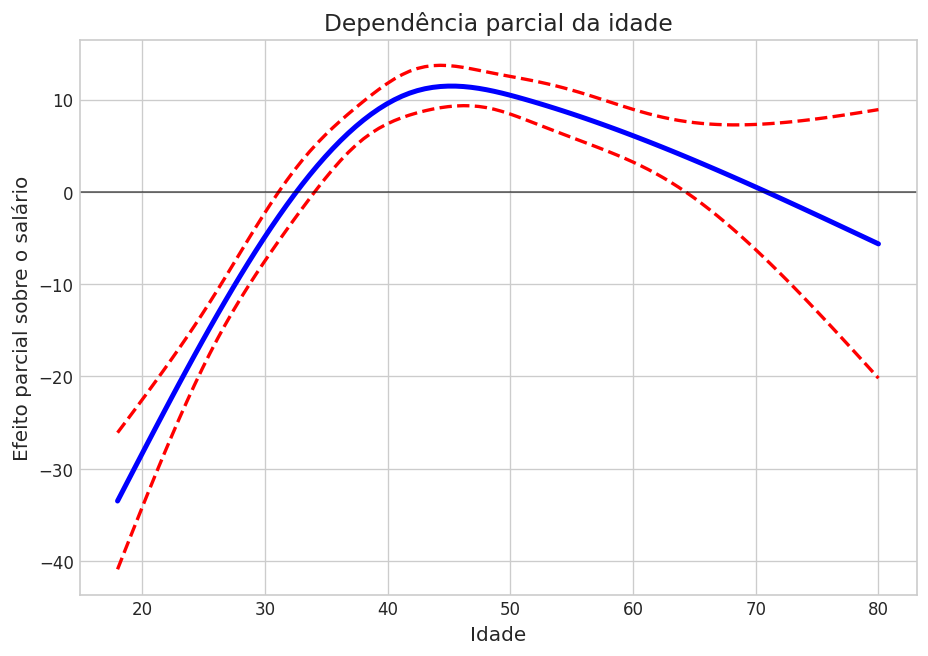

In [23]:
age_grid = np.linspace(age.min(), age.max(), 100)
X_age_bh = np.tile(X_bh.mean(axis=0), (len(age_grid), 1))
X_age_bh[:, :4] = ns_age_manual.transform(age_grid)

preds_age_manual = gam_manual.get_prediction(X_age_bh)
bounds_age = preds_age_manual.conf_int(alpha=0.05)
partial_age = preds_age_manual.predicted_mean.copy()
center_age = partial_age.mean()
partial_age -= center_age
bounds_age -= center_age

fig, ax = subplots(figsize=(9, 6))
ax.plot(age_grid, partial_age, "b", linewidth=3)
ax.plot(age_grid, bounds_age[:, 0], "r--", linewidth=2)
ax.plot(age_grid, bounds_age[:, 1], "r--", linewidth=2)
ax.axhline(0, color="black", linewidth=1, alpha=0.6)
ax.set_xlabel("Idade")
ax.set_ylabel("Efeito parcial sobre o salário")
ax.set_title("Dependência parcial da idade")
plt.show()

Mantidos ano e escolaridade constantes, o efeito estimado de idade cresce rapidamente no início, estabiliza e cai depois. A centralização muda apenas o nível vertical, sem alterar a forma. As bandas descrevem incerteza da média ajustada sob o modelo; não são intervalos de previsão para salários individuais.

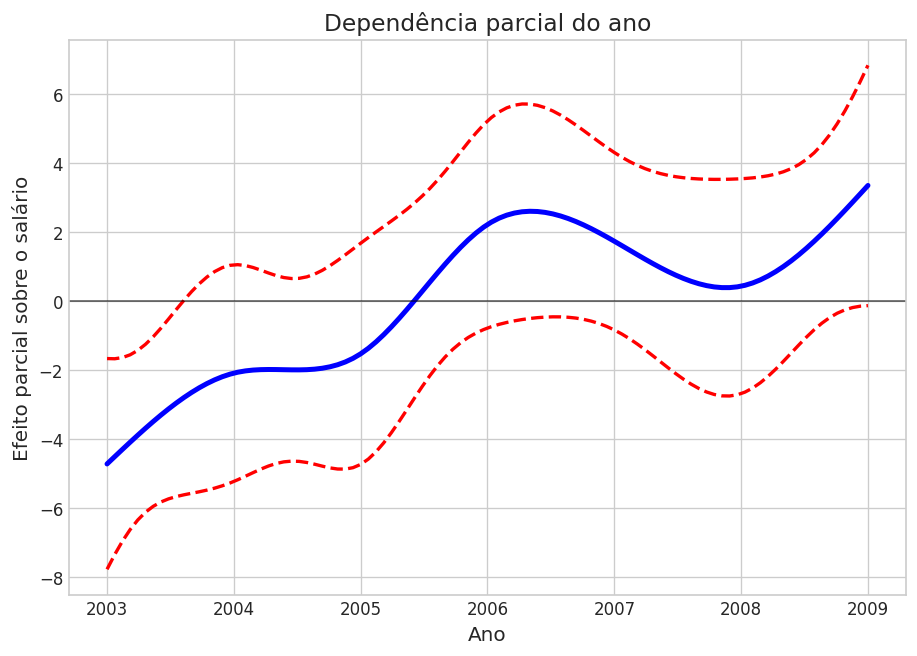

In [24]:
year_grid = np.linspace(Wage["year"].min(), Wage["year"].max(), 100)
X_year_bh = np.tile(X_bh.mean(axis=0), (len(year_grid), 1))
X_year_bh[:, 4:9] = ns_year_manual.transform(year_grid)

preds_year_manual = gam_manual.get_prediction(X_year_bh)
bounds_year = preds_year_manual.conf_int(alpha=0.05)
partial_year = preds_year_manual.predicted_mean.copy()
center_year = partial_year.mean()
partial_year -= center_year
bounds_year -= center_year

fig, ax = subplots(figsize=(9, 6))
ax.plot(year_grid, partial_year, "b", linewidth=3)
ax.plot(year_grid, bounds_year[:, 0], "r--", linewidth=2)
ax.plot(year_grid, bounds_year[:, 1], "r--", linewidth=2)
ax.axhline(0, color="black", linewidth=1, alpha=0.6)
ax.set_xlabel("Ano")
ax.set_ylabel("Efeito parcial sobre o salário")
ax.set_title("Dependência parcial do ano")
plt.show()

O efeito de ano varia pouco quando comparado ao efeito de idade. A spline desenha algumas oscilações, mas as bandas são largas e o gráfico sozinho não mostra se a curvatura justifica a complexidade. A ANOVA entre GAMs fará essa comparação.

## GAM com `pygam`

Ajustamos idade e ano por splines de suavização e escolaridade como fator. O ano possui apenas sete valores distintos, por isso usamos sete funções de base. `lam=0` no fator evita encolhimento artificial entre categorias de escolaridade.

In [25]:
Xgam = np.column_stack([
    age,
    Wage["year"],
    Wage["education"].cat.codes,
])

gam_full_default = LinearGAM(
    s_gam(0)
    + s_gam(1, n_splines=7)
    + f_gam(2, lam=0)
).fit(Xgam, y)

gam_full_default

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + s(1) + f(2) + intercept, 
   tol=0.0001, verbose=False)

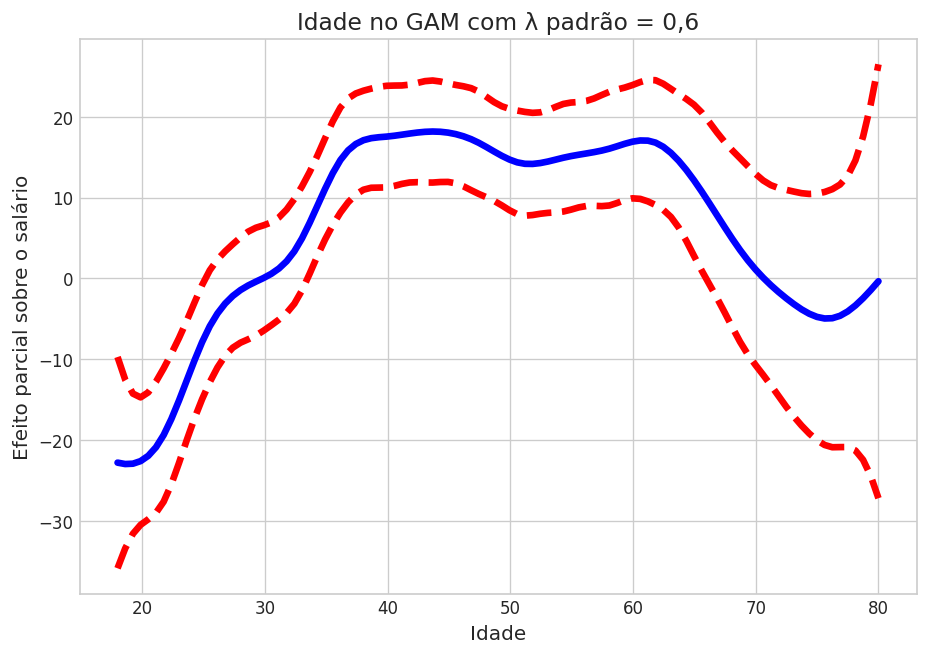

In [26]:
fig, ax = subplots(figsize=(9, 6))
plot_gam(gam_full_default, 0, ax=ax)
ax.set_xlabel("Idade")
ax.set_ylabel("Efeito parcial sobre o salário")
ax.set_title("Idade no GAM com λ padrão = 0,6")
plt.show()

Com o valor padrão de $\lambda=0{,}6$, o efeito de idade apresenta oscilações que podem ser difíceis de justificar. Em vez de aceitar uma penalização arbitrária, fixamos aproximadamente quatro graus de liberdade para idade e ano.

In [27]:
gam_full = LinearGAM(
    s_gam(0)
    + s_gam(1, n_splines=7)
    + f_gam(2, lam=0)
).fit(Xgam, y)

age_term = gam_full.terms[0]
age_term.lam = approx_lam(Xgam, age_term, df=4 + 1)

year_term = gam_full.terms[1]
year_term.lam = approx_lam(Xgam, year_term, df=4 + 1)

gam_full = gam_full.fit(Xgam, y)

print("λ de idade:", age_term.lam)
print("λ de ano:", year_term.lam)
print("Graus de liberdade efetivos totais:",
      round(gam_full.statistics_["edof"], 3))

λ de idade: [465.04913847]
λ de ano: [2.15642074]
Graus de liberdade efetivos totais: 12.993


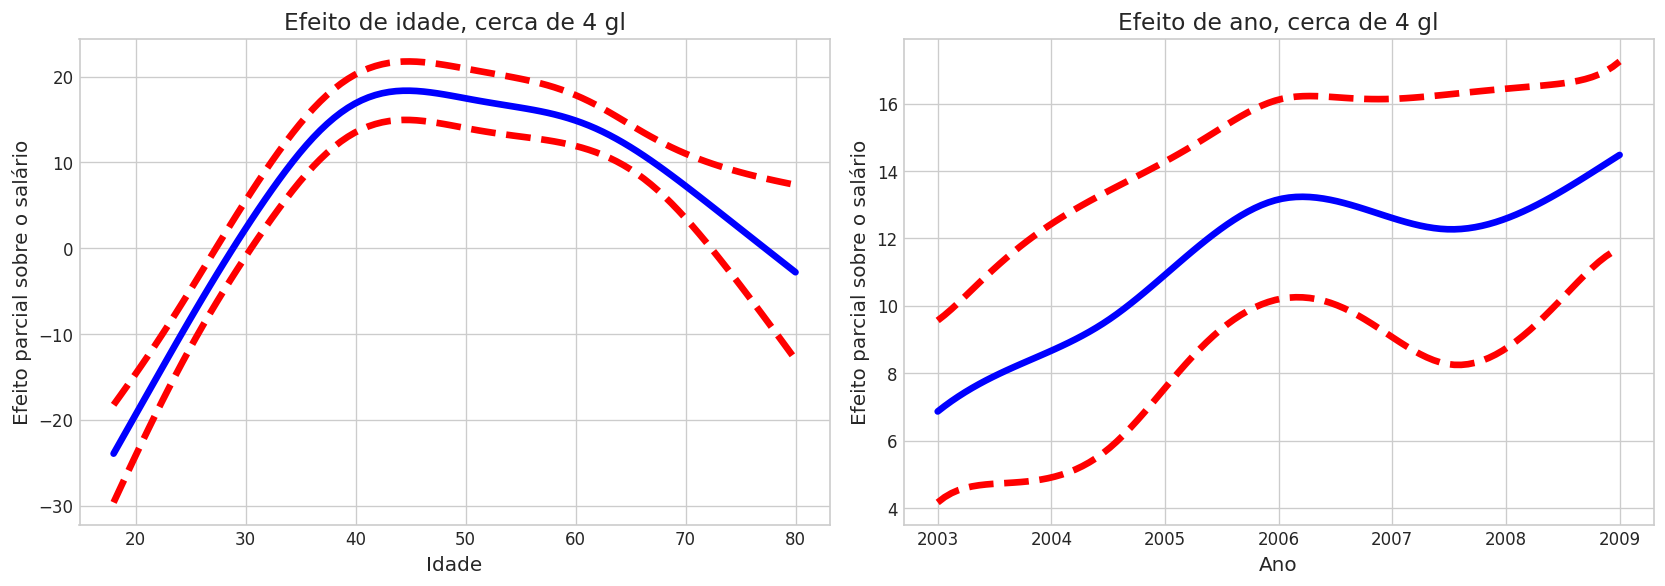

In [28]:
fig, axes = subplots(1, 2, figsize=(14, 5))

plot_gam(gam_full, 0, ax=axes[0])
axes[0].set_xlabel("Idade")
axes[0].set_ylabel("Efeito parcial sobre o salário")
axes[0].set_title("Efeito de idade, cerca de 4 gl")

plot_gam(gam_full, 1, ax=axes[1])
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Efeito parcial sobre o salário")
axes[1].set_title("Efeito de ano, cerca de 4 gl")

plt.tight_layout()
plt.show()

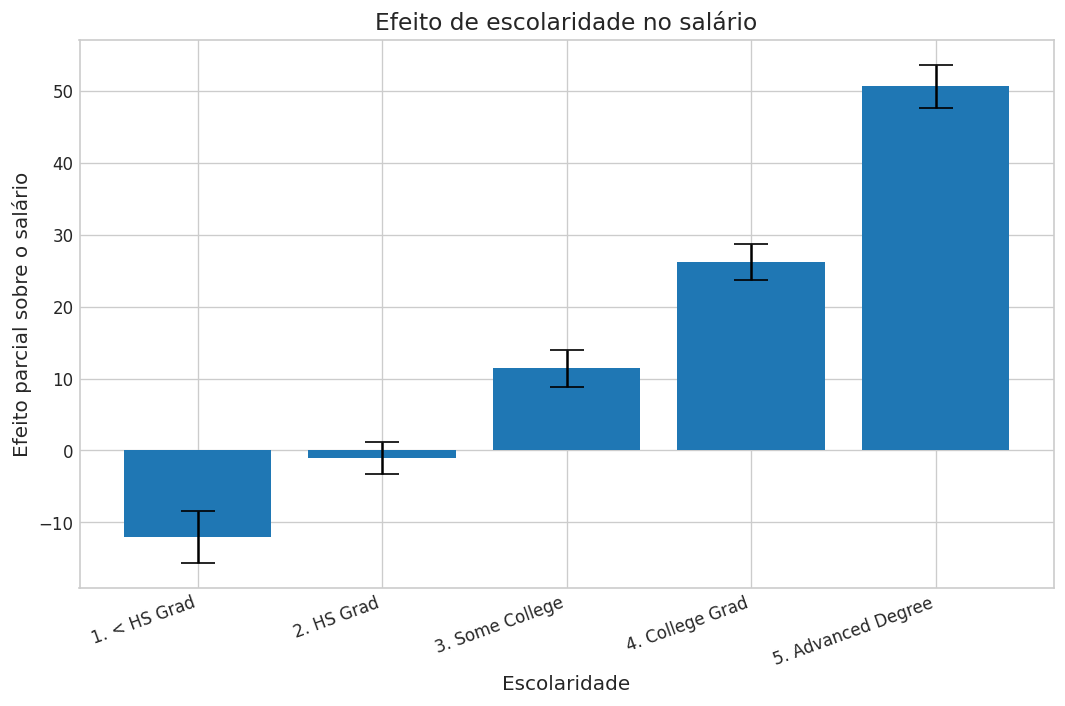

In [29]:
fig, ax = subplots(figsize=(9, 6))
plot_gam(gam_full, 2, ax=ax)
ax.set_xlabel("Escolaridade")
ax.set_ylabel("Efeito parcial sobre o salário")
ax.set_title("Efeito de escolaridade no salário")
ax.set_xticks(range(len(Wage["education"].cat.categories)))
ax.set_xticklabels(Wage["education"].cat.categories, rotation=20, ha="right")
plt.tight_layout()
plt.show()

O ajuste controlado por graus de liberdade produz uma curva de idade mais estável. O efeito de ano permanece quase linear. Escolaridade aparece como um conjunto de constantes: cada ponto representa o efeito parcial estimado de uma categoria, mantendo idade e ano controlados. As categorias mais altas estão associadas a salários maiores.

Esses efeitos são associativos. O modelo não identifica efeito causal da escolaridade porque não controla todas as diferenças que influenciam simultaneamente escolaridade e remuneração.

## Testes ANOVA para os termos do GAM

Para `year`, comparamos três modelos aninhados:

- M1: exclui ano;
- M2: usa ano de forma linear;
- M3: usa spline de suavização para ano.

In [30]:
gam_sem_ano = LinearGAM(
    age_term + f_gam(2, lam=0)
).fit(Xgam, y)

gam_ano_linear = LinearGAM(
    age_term + l_gam(1, lam=0) + f_gam(2, lam=0)
).fit(Xgam, y)

anova_ano = anova_gam(gam_sem_ano, gam_ano_linear, gam_full)
anova_ano.index = ["sem ano", "ano linear", "ano com spline"]
anova_ano

,deviance,df,deviance_diff,df_diff,F,pvalue
sem ano,"105,402.4322","2,991.0040",NaN,NaN,NaN,NaN
ano linear,"105,134.6242","2,990.0052",267.8080,0.9988,7.6253,0.0162
ano com spline,"105,030.6847","2,987.0073",103.9395,2.9979,0.9860,0.4296


A passagem de “sem ano” para “ano linear” reduz o desvio com valor-p próximo de 0,016 na versão atual das bibliotecas. A spline não melhora o modelo linear de forma convincente, com valor-p em torno de 0,43. M2 é a escolha apoiada pelo teste: ano deve entrar no modelo, mas a curvatura extra não se justifica. O capítulo registra cerca de 0,002 para a primeira comparação; a diferença numérica decorre de mudanças de versão no `pygam` e no cálculo auxiliar da ANOVA, sem alterar a decisão substantiva.

Repetimos o raciocínio para idade:

- M1: exclui idade;
- M2: usa idade linear;
- M3: usa spline de suavização para idade.

In [31]:
gam_sem_idade = LinearGAM(
    year_term + f_gam(2, lam=0)
).fit(Xgam, y)

gam_idade_linear = LinearGAM(
    l_gam(0, lam=0) + year_term + f_gam(2, lam=0)
).fit(Xgam, y)

anova_idade = anova_gam(gam_sem_idade, gam_idade_linear, gam_full)
anova_idade.index = ["sem idade", "idade linear", "idade com spline"]
anova_idade

,deviance,df,deviance_diff,df_diff,F,pvalue
sem idade,"109,043.8100","2,991.0006",NaN,NaN,NaN,NaN
idade linear,"107,295.1116","2,990.0007","1,748.6984",0.9999,49.7376,0.0000
idade com spline,"105,030.6847","2,987.0073","2,264.4269",2.9935,21.5133,0.0000


Os dois ganhos apresentam valores-p muito pequenos. Idade melhora o ajuste e sua relação com salário não é adequadamente representada por uma reta. Esse resultado formaliza o padrão observado nos gráficos.

O `pygam` oferece um resumo extenso. Ele é exibido abaixo por completude. O próprio pacote alerta que os valores-p de termos suavizados podem ser excessivamente otimistas quando os parâmetros de suavização são estimados. As comparações de modelos acima respondem melhor à escolha entre ausência, linearidade e não linearidade.

In [32]:
gam_full.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     12.9927
Link Function:                     IdentityLink Log Likelihood:                                 -14930.261
Number of Samples:                         3000 AIC:                                            29888.5074
                                                AICc:                                            29888.648
                                                GCV:                                             1246.1129
                                                Scale:                                             35.1625
                                                Pseudo R-Squared:                                   0.2928
Feature Function                  Lam

<notebook-cell>:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 



## Desempenho do GAM gaussiano no treinamento

O capítulo mostra como obter previsões. Acrescentamos RMSE e $R^2$ para dar escala ao ajuste. Como as métricas usam os mesmos dados empregados na estimação, são diagnósticos descritivos e tendem a ser otimistas.

In [33]:
Yhat = gam_full.predict(Xgam)
rmse_treino = np.sqrt(np.mean((y - Yhat) ** 2))
r2_treino = 1 - np.sum((y - Yhat) ** 2) / np.sum((y - y.mean()) ** 2)

print(f"RMSE no treinamento: {rmse_treino:.3f} mil US$")
print(f"R² no treinamento: {r2_treino:.4f}")

RMSE no treinamento: 35.086 mil US$
R² no treinamento: 0.2928


## GAM logístico para alta renda

Trocamos `LinearGAM()` por `LogisticGAM()` e modelamos a probabilidade de salário acima de US$ 250 mil. O primeiro ajuste inclui todas as categorias de escolaridade para revelar o problema presente nos dados.

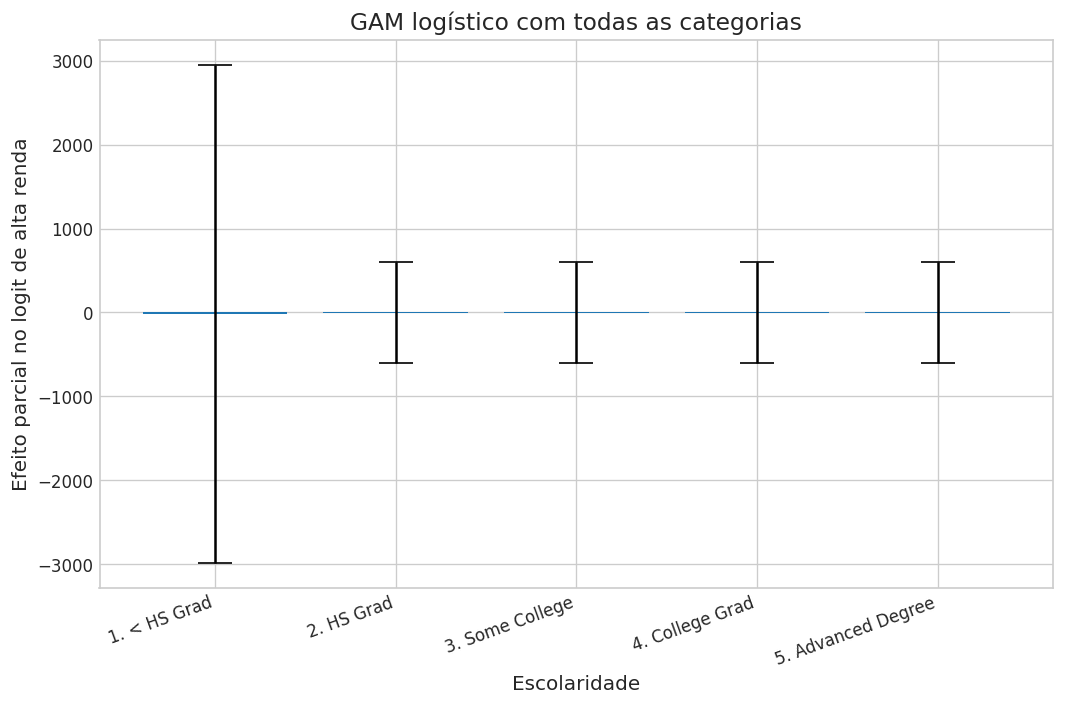

In [34]:
gam_logit = LogisticGAM(
    age_term + l_gam(1, lam=0) + f_gam(2, lam=0)
).fit(Xgam, high_earn)

fig, ax = subplots(figsize=(9, 6))
plot_gam(gam_logit, 2, ax=ax)
ax.set_xlabel("Escolaridade")
ax.set_ylabel("Efeito parcial no logit de alta renda")
ax.set_title("GAM logístico com todas as categorias")
ax.set_xticks(range(len(Wage["education"].cat.categories)))
ax.set_xticklabels(Wage["education"].cat.categories, rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [35]:
tabela_alta_renda = pd.crosstab(
    Wage["education"],
    Wage["high_earn"],
    rownames=["Escolaridade"],
    colnames=["Alta renda"],
)
tabela_alta_renda

Alta renda,False,True
Escolaridade,,
1. < HS Grad,268,0
2. HS Grad,966,5
3. Some College,643,7
4. College Grad,663,22
5. Advanced Degree,381,45


A primeira categoria de escolaridade não contém qualquer caso de alta renda. Isso cria separação completa para esse nível: o modelo tenta empurrar sua probabilidade para zero, o coeficiente pode divergir e o intervalo de confiança fica muito amplo. Não se trata apenas de “pouca significância”; falta variação do desfecho dentro da categoria.

Para reproduzir a solução didática do capítulo, retiramos esse grupo e reconstruímos a matriz. Os códigos das categorias são deslocados em uma unidade para ficar entre 0 e 3, formato esperado pelo termo fatorial do `pygam`.

In [36]:
only_hs = Wage["education"] == "1. < HS Grad"
Wage_sem_hs = Wage.loc[~only_hs].copy()

Xgam_sem_hs = np.column_stack([
    Wage_sem_hs["age"],
    Wage_sem_hs["year"],
    Wage_sem_hs["education"].cat.codes - 1,
])
high_earn_sem_hs = Wage_sem_hs["high_earn"]

print(f"Observações removidas: {only_hs.sum()}")
print(f"Observações mantidas: {len(Wage_sem_hs)}")

Observações removidas: 268
Observações mantidas: 2732


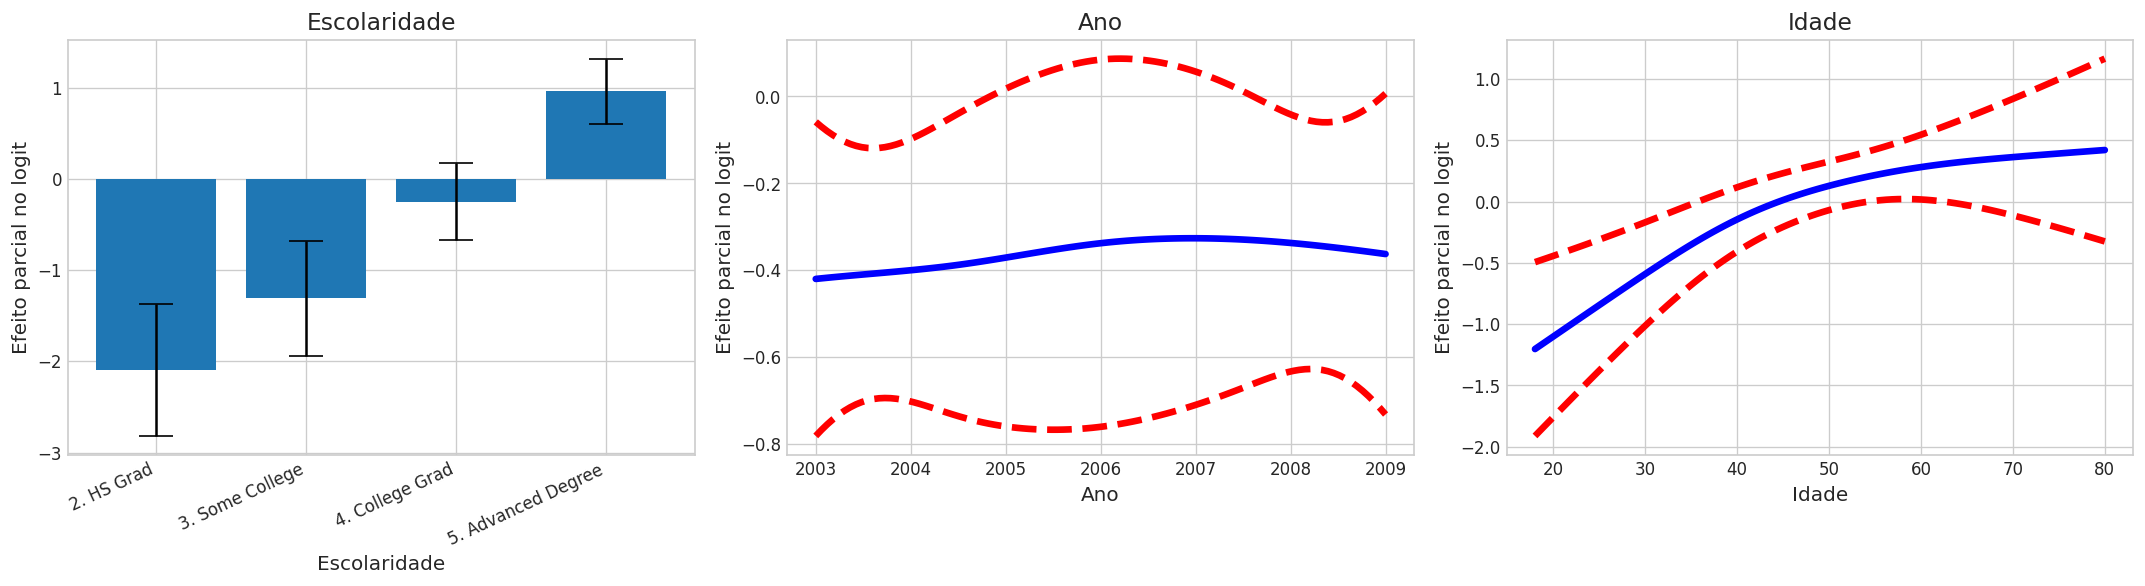

In [37]:
gam_logit_sem_hs = LogisticGAM(
    age_term + year_term + f_gam(2, lam=0)
).fit(Xgam_sem_hs, high_earn_sem_hs)

fig, axes = subplots(1, 3, figsize=(18, 5))

plot_gam(gam_logit_sem_hs, 2, ax=axes[0])
axes[0].set_xlabel("Escolaridade")
axes[0].set_ylabel("Efeito parcial no logit")
axes[0].set_title("Escolaridade")
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(
    Wage["education"].cat.categories[1:], rotation=25, ha="right"
)

plot_gam(gam_logit_sem_hs, 1, ax=axes[1])
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Efeito parcial no logit")
axes[1].set_title("Ano")

plot_gam(gam_logit_sem_hs, 0, ax=axes[2])
axes[2].set_xlabel("Idade")
axes[2].set_ylabel("Efeito parcial no logit")
axes[2].set_title("Idade")

plt.tight_layout()
plt.show()

Estes gráficos reproduzem a lógica da Figura 7.14. Depois da retirada do grupo sem eventos, o efeito de escolaridade fica ordenado e interpretável: níveis educacionais mais altos estão associados a maior chance de alta renda. O efeito de ano é pequeno diante das bandas de incerteza. O efeito de idade cresce com força nas idades iniciais e perde inclinação na meia-idade, sem evidência visual clara de queda no intervalo final.

O eixo vertical está na escala do preditor linear, o *logit*, e mostra efeitos parciais centralizados. Ele não deve ser lido diretamente como variação em pontos percentuais. Para comunicar probabilidades, seria necessário gerar perfis completos, fixar as demais variáveis e aplicar a transformação logística.

A exclusão resolve o exemplo gráfico, mas muda a população analisada. Em uma aplicação real, registraríamos explicitamente que as conclusões valem para pessoas com ensino médio completo ou mais. Poderíamos estudar métodos próprios para separação ou agrupar categorias apenas se houver justificativa substantiva.

# 7.8.4 Regressão local

A regressão local ajusta pequenos modelos em vizinhanças do ponto em que queremos prever. O parâmetro `frac` determina a fração da amostra usada em cada vizinhança:

- `frac=0.2` usa 20% das observações e produz uma curva mais sensível;
- `frac=0.5` usa 50% e produz uma curva mais suave.

Algumas bibliotecas permitem termos de regressão local dentro de GAMs. O `pygam` usado aqui não oferece esse operador, então aplicamos `statsmodels.nonparametric.lowess` diretamente.

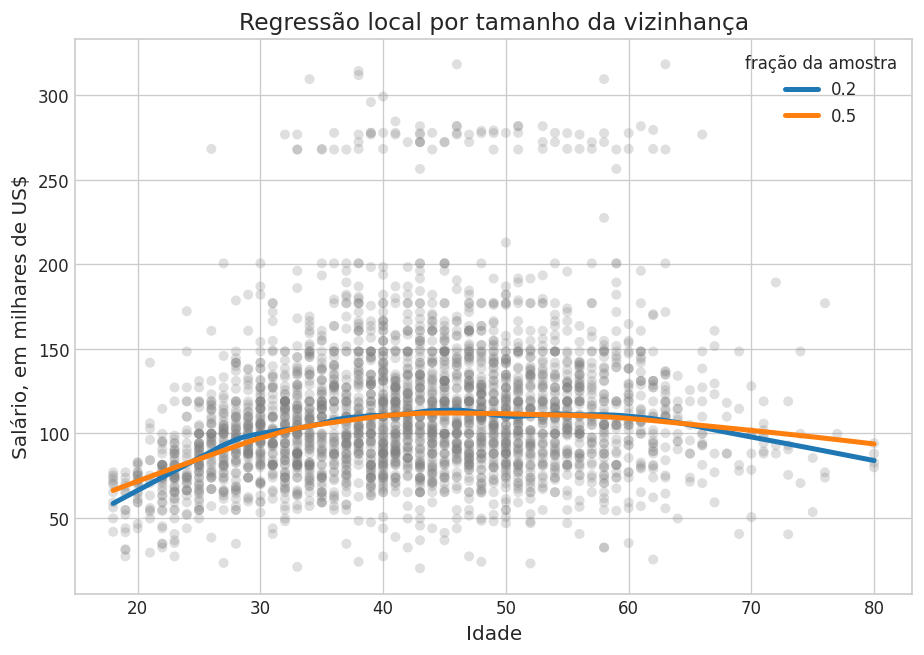

In [38]:
lowess = sm.nonparametric.lowess

fig, ax = subplots(figsize=(9, 6))
ax.scatter(age, y, facecolor="gray", edgecolor="none", alpha=0.25)

for span in [0.2, 0.5]:
    fitted = lowess(
        y,
        age,
        frac=span,
        xvals=age_grid,
    )
    ax.plot(age_grid, fitted, label=f"{span:.1f}", linewidth=3)

ax.set_xlabel("Idade")
ax.set_ylabel("Salário, em milhares de US$")
ax.set_title("Regressão local por tamanho da vizinhança")
ax.legend(title="fração da amostra")
plt.show()

A curva com vizinhança de 20% acompanha mais variações locais. A de 50% resume o padrão geral e reduz pequenas ondulações. Ambas identificam crescimento salarial nas idades iniciais, um platô na meia-idade e queda posterior.

O parâmetro de vizinhança exerce papel semelhante ao de $\lambda$ nas splines de suavização, mas em direção inversa: uma vizinhança maior aumenta a suavização, enquanto um $\lambda$ maior aumenta a penalização. A regressão local é útil para exploração em baixa dimensão, mas não fornece uma representação paramétrica compacta e se torna mais difícil de usar conforme cresce o número de variáveis.

# Síntese comparativa

| Método | Como controla a flexibilidade | Ponto forte | Limitação principal neste exemplo |
|---|---|---|---|
| Polinômio | Grau | Simples de ajustar e testar por modelos aninhados | Comportamento global e caudas instáveis |
| Função degrau | Número e posição dos cortes | Fácil de explicar | Saltos artificiais e perda de informação contínua |
| B-spline | Grau, nós ou graus de liberdade | Flexibilidade local | Coeficientes da base não têm leitura isolada |
| Spline natural | Nós ou graus de liberdade, com caudas lineares | Mais estável nas fronteiras | A escolha da complexidade ainda precisa ser validada |
| Spline de suavização | $\lambda$ ou graus de liberdade efetivos | Ajuste contínuo com penalização explícita | Penalização pequena pode gerar ondulações espúrias |
| GAM | Complexidade de cada termo | Combina relações não lineares e fatores de forma aditiva | Não captura interações sem especificá-las |
| Regressão local | Fração da vizinhança | Boa ferramenta exploratória em baixa dimensão | Escala mal para muitas variáveis |

## Conclusões do laboratório

1. A associação entre idade e salário é não linear. Os testes rejeitam a forma puramente linear e os gráficos mostram crescimento, estabilização e queda.
2. O efeito de ano é relevante, mas uma forma linear é suficiente dentro do período observado.
3. Escolaridade mais alta está associada a salários e probabilidades de alta renda maiores após controlar idade e ano.
4. A ausência de casos de alta renda no grupo `< HS` produz separação no GAM logístico e impede uma estimação estável desse efeito.
5. Complexidade deve ser escolhida com teste ou validação. Uma curva mais ondulada sempre reduz algum erro de treinamento, mas pode representar ruído.

Para uso preditivo, o próximo passo seria comparar essas alternativas por validação cruzada com uma métrica adequada ao problema. Para salário contínuo, RMSE ou MAE. Para alta renda, log loss, Brier score, discriminação e calibração.